# 03. Fair Representation Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Assess representation and inclusion in data and design
- Address underrepresentation and stereotyping
- Promote equitable outcomes across groups

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# 03. Fair Representation Learning

## 🚨 THE PROBLEM: Data Doesn't Represent Groups Fairly

**Remember the limitation from the previous notebook?**

We learned how to mitigate bias using pre-processing, in-processing, and post-processing techniques. But we discovered:

**What if the data itself doesn't represent groups fairly?**

**The Problem**: Even with mitigation techniques, if the data doesn't represent groups fairly:
- Mitigation techniques may not work effectively
- We can't fix what's not in the data
- Underrepresented groups may still be disadvantaged
- Historical biases persist in the data

**We've learned:**
- ✅ How to detect bias (Notebook 1)
- ✅ How to mitigate bias (Notebook 2)
- ✅ That data representation matters

**But we haven't learned:**
- ❌ How to **ensure fair representation** in data
- ❌ How to **remove bias from features** themselves
- ❌ How to **transform features** to be fair

**We need fair representation techniques** to:
1. Remove bias from feature representations
2. Ensure all groups are fairly represented in the data
3. Transform features to remove sensitive information
4. Create fair datasets from the start

**This notebook solves that problem** by teaching you fair representation learning techniques like PCA, autoencoders, and adversarial debiasing!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Bias Detection** - Understanding how to detect bias
- ✅ **Example 2: Bias Mitigation** - Understanding mitigation techniques
- ✅ **Basic Python knowledge**: Functions, data manipulation, ML concepts
- ✅ **Understanding of neural networks**: Autoencoders, PCA (helpful but not required)

**If you haven't completed these**, you might struggle with:
- Understanding why fair representation matters
- Knowing how to remove bias from feature representations
- Understanding different fair representation techniques

---

## 🔗 Where This Notebook Fits

**This is the THIRD example in Unit 2** - it teaches you how to ensure fair representation in your data!

**Why this example THIRD?**
- **Before** you can ensure fair representation, you need to detect bias (Example 1)
- **Before** you can learn fair representation, you need to understand mitigation (Example 2)
- **Before** you can build fair systems, you need fair representation techniques

**Builds on**: 
- 📓 Example 1: Bias Detection (we detected bias)
- 📓 Example 2: Bias Mitigation (we learned to fix bias)

**Leads to**: 
- 📓 Example 4: Bias Case Studies (analyzing real bias cases)
- 📓 Example 5: Fair AI Development (building fair AI systems)

**Why this order?**
1. Fair representation provides **data-level solutions** (complements mitigation)
2. Fair representation teaches **feature transformation** (critical skill)
3. Fair representation shows **advanced techniques** (PCA, autoencoders, adversarial)

---

## The Story: Fair Features for Fair Models

Imagine you're a chef preparing ingredients. **Before** cooking, you need to prepare ingredients properly - wash vegetables, remove spoiled parts, cut uniformly. **After** preparation, you have clean, uniform ingredients that make better dishes!

Same with AI: **Before** we have features that may contain bias, now we transform them to remove bias - use PCA, autoencoders, or adversarial techniques. **After** fair representation, we have features that don't encode bias!

---

## Why Fair Representation Matters

Fair representation is essential for ethical AI:
- **Remove Bias from Features**: Transform features to remove sensitive information
- **Better Generalization**: Fair features lead to more generalizable models
- **Privacy Protection**: Remove sensitive information from representations
- **Compliance**: Meet fairness requirements at the data level
- **Foundation for Fairness**: Fair representation is the foundation for fair models

## Learning Objectives
1. Understand what fair representation means
2. Learn PCA for bias removal
3. Learn autoencoders for feature transformation
4. Learn adversarial debiasing techniques
5. Compare effectiveness of different fair representation methods
6. Understand when to use each technique

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us implement fair representation learning techniques

import numpy as np  # For numerical operations: Arrays, calculations, random number generation
import pandas as pd  # For data manipulation: DataFrames, data analysis
import matplotlib.pyplot as plt  # For creating visualizations: Charts, graphs, comparisons
import seaborn as sns  # For statistical visualizations: Heatmaps, advanced plots
from sklearn.model_selection import train_test_split  # For splitting data: Separate training and testing sets
from sklearn.decomposition import PCA  # For dimensionality reduction: Principal Component Analysis
from sklearn.preprocessing import StandardScaler  # For data preprocessing: Feature scaling
from sklearn.ensemble import RandomForestClassifier  # For ML model: Classification algorithm
from sklearn.metrics import accuracy_score  # For model evaluation: Accuracy metric
from sklearn.neural_network import MLPRegressor  # For neural networks: Autoencoder implementation
import warnings  # For suppressing warnings: Clean output
import os  # For file operations: Saving images

# Suppress warnings: Clean output (neural networks may show warnings)
warnings.filterwarnings('ignore')  # Ignore warnings: Suppress non-critical warnings

# Configure plotting: Set default styles for better visualizations
plt.rcParams['font.size'] = 10  # Font size: Make text readable (10pt is good for most displays)
plt.rcParams['figure.figsize'] = (14, 8)  # Figure size: 14 inches wide, 8 inches tall (good for detailed charts)
sns.set_style("whitegrid")  # Style: White background with grid for clean look

print(" Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - numpy/pandas: Data manipulation and numerical operations")
print("   - matplotlib/seaborn: Create visualizations (charts, heatmaps)")
print("   - sklearn: Machine learning (PCA, models, metrics, preprocessing)")
print("   - sklearn.neural_network: Neural networks (autoencoders)")
print("   - os: File operations (saving images)")


 Libraries imported successfully!

📚 What each library does:
   - numpy/pandas: Data manipulation and numerical operations
   - matplotlib/seaborn: Create visualizations (charts, heatmaps)
   - sklearn: Machine learning (PCA, models, metrics, preprocessing)
   - sklearn.neural_network: Neural networks (autoencoders)
   - os: File operations (saving images)


## Part 2: Understanding Fair Representation

### 📚 Prerequisites (What You Need First)
- **Library imports** (from Part 1) - Understanding ML and neural network tools
- **Understanding of bias** (from Examples 1-2) - Knowing what bias looks like

### 🔗 Relationship: What This Builds On
This builds on bias detection and mitigation - we now ensure features are fair!
- Builds on: Bias detection skills, understanding of mitigation
- Shows: How to transform features to remove bias

### 📖 The Story
**Before fair representation**: We have features that may encode bias.
**After fair representation**: We have transformed features that carry much less sensitive information!

In [2]:
# Step 2: Generate synthetic dataset with features correlated with the
# sensitive attribute - so we can practice removing that correlation

print("\n" + "="*80)
print("📊 GENERATING DATASET WITH FEATURE-SENSITIVE CORRELATION")
print("="*80)

def generate_biased_dataset(n_samples=2000):
    """
    Generate dataset where some features are correlated with the sensitive
    attribute (X1, X2 correlated; X3, X4 independent).
    """
    np.random.seed(42)
    sensitive = np.random.binomial(1, 0.5, n_samples)
    X1 = np.random.normal(0, 1, n_samples) + 0.5 * sensitive   # correlated
    X2 = np.random.normal(0, 1, n_samples) + 0.3 * sensitive   # correlated
    X3 = np.random.normal(0, 1, n_samples)                     # independent
    X4 = np.random.normal(0, 1, n_samples)                     # independent
    y = (0.4*X1 + 0.3*X2 + 0.2*X3 + 0.1*X4
         + np.random.normal(0, 0.1, n_samples) > 0).astype(int)
    return pd.DataFrame({'feature1': X1, 'feature2': X2, 'feature3': X3,
                         'feature4': X4, 'sensitive': sensitive, 'target': y})

df = generate_biased_dataset(n_samples=2000)
print(f"Generated dataset with {len(df)} samples")
print("\nCorrelation of each feature with the sensitive attribute:")
for col in ['feature1', 'feature2', 'feature3', 'feature4']:
    corr = np.corrcoef(df[col], df['sensitive'])[0, 1]
    print(f"  {col}: {corr:+.3f}")
print("\nX1 and X2 leak group membership - fair representation should remove that!")



📊 GENERATING DATASET WITH FEATURE-SENSITIVE CORRELATION
Generated dataset with 2000 samples

Correlation of each feature with the sensitive attribute:
  feature1: +0.254
  feature2: +0.121
  feature3: +0.001
  feature4: -0.002

X1 and X2 leak group membership - fair representation should remove that!


## Part 3: Three Fair Representation Techniques

1. **PCA**: project features onto principal components; check how much sensitive
   correlation survives in the new space.
2. **Autoencoder** (a small MLP trained to reconstruct its input): use the learned
   compressed representation as new features.
3. **Adversarial debiasing** (simplified): train an *adversary* to predict the sensitive
   attribute from the features - if the adversary succeeds, the features still leak
   sensitive information. (Full adversarial training alternates model vs adversary;
   here we only demonstrate the adversary-as-a-leak-detector idea.)

In [3]:
# Why: fair representation learning transforms the FEATURES so they stop
# encoding group membership - then any downstream model is starved of the bias signal.

# Step 3: Define the fair representation techniques
from sklearn.linear_model import LogisticRegression  # adversary model

def fair_representation_pca(X, sensitive, n_components=2):
    """Project onto principal components; measure leftover sensitive correlation."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=n_components)
    X_transformed = pca.fit_transform(X_scaled)
    correlations = [abs(np.corrcoef(X_transformed[:, i], sensitive)[0, 1])
                    for i in range(n_components)]
    return X_transformed, correlations, pca, scaler

def train_autoencoder(X, encoding_dim=2):
    """Train a small MLP autoencoder (encoder + decoder) with sklearn."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    encoder = MLPRegressor(hidden_layer_sizes=(X.shape[1], encoding_dim),
                           activation='relu', solver='adam', max_iter=500,
                           random_state=42)
    encoder.fit(X_scaled, X_scaled)          # learn to reconstruct input
    # sklearn's MLP does not expose hidden activations, so we approximate the
    # 2-dim bottleneck code: take the network's reconstruction (which had to
    # pass through the small hidden layer) and compress it to encoding_dim
    # with PCA. The result reflects what survived the bottleneck.
    recon = encoder.predict(X_scaled)
    pca = PCA(n_components=encoding_dim)
    encoded = pca.fit_transform(recon)
    return encoder, scaler, pca, encoded

def evaluate_fairness(X_transformed, sensitive, method_name):
    """How much sensitive-attribute correlation survives the transformation?"""
    correlations = [abs(np.corrcoef(X_transformed[:, i], sensitive)[0, 1])
                    for i in range(X_transformed.shape[1])]
    avg_c, max_c = np.mean(correlations), np.max(correlations)
    print(f"\n{method_name}:")
    print(f"  Average correlation with sensitive attribute: {avg_c:.4f}")
    print(f"  Maximum correlation: {max_c:.4f}")
    return avg_c, max_c

def adversarial_leak_test(X, sensitive):
    """Adversary tries to predict the sensitive attribute from features.
    Accuracy near 0.5 = little leakage; near 1.0 = heavy leakage."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(np.asarray(X))
    adversary = LogisticRegression(random_state=42, max_iter=1000)
    adversary.fit(X_scaled, sensitive)
    return accuracy_score(sensitive, adversary.predict(X_scaled))

print("Fair representation functions defined (PCA, autoencoder, adversary test).")

Fair representation functions defined (PCA, autoencoder, adversary test).


In [4]:
# Why compare: each representation trades some task signal for less group leakage -
# we measure both (accuracy + adversary accuracy) to see the trade-off honestly.

# Step 4: Compare original features vs PCA vs autoencoder representations

X = df[['feature1', 'feature2', 'feature3', 'feature4']].values
y = df['target'].values
sensitive = df['sensitive'].values
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X, y, sensitive, test_size=0.3, random_state=42, stratify=y)

results = {}

# 1. Baseline: original features
print("="*80); print("1. BASELINE: Original Features"); print("="*80)
corr_orig = [abs(np.corrcoef(X_train[:, i], sensitive_train)[0, 1])
             for i in range(X_train.shape[1])]
print(f"Average correlation with sensitive attribute: {np.mean(corr_orig):.4f}")
scaler_orig = StandardScaler()
X_train_s = scaler_orig.fit_transform(X_train)
X_test_s = scaler_orig.transform(X_test)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_s, y_train)
acc = accuracy_score(y_test, model.predict(X_test_s))
print(f"Classification accuracy: {acc:.4f}")
adv_acc = adversarial_leak_test(X_train, sensitive_train)
print(f"Adversary accuracy (predicting sensitive attribute): {adv_acc:.4f}")
results['Original'] = {'correlation': np.mean(corr_orig), 'accuracy': acc,
                       'adversary': adv_acc, 'features': X_train_s}

# 2. PCA-based representation
print("\n" + "="*80); print("2. PCA-BASED FAIR REPRESENTATION"); print("="*80)
X_pca, _, pca, scaler_pca = fair_representation_pca(X_train, sensitive_train, 2)
avg_corr, _ = evaluate_fairness(X_pca, sensitive_train, "PCA")
X_test_pca = pca.transform(scaler_pca.transform(X_test))
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_pca, y_train)
acc = accuracy_score(y_test, model.predict(X_test_pca))
print(f"Classification accuracy: {acc:.4f}")
adv_acc = adversarial_leak_test(X_pca, sensitive_train)
print(f"Adversary accuracy: {adv_acc:.4f}")
results['PCA'] = {'correlation': avg_corr, 'accuracy': acc,
                  'adversary': adv_acc, 'features': X_pca}

# 3. Autoencoder-based representation
print("\n" + "="*80); print("3. AUTOENCODER-BASED FAIR REPRESENTATION"); print("="*80)
encoder, scaler_ae, pca_ae, X_encoded = train_autoencoder(X_train, encoding_dim=2)
avg_corr, _ = evaluate_fairness(X_encoded, sensitive_train, "Autoencoder")
X_test_encoded = pca_ae.transform(encoder.predict(scaler_ae.transform(X_test)))
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_encoded, y_train)
acc = accuracy_score(y_test, model.predict(X_test_encoded))
print(f"Classification accuracy: {acc:.4f}")
adv_acc = adversarial_leak_test(X_encoded, sensitive_train)
print(f"Adversary accuracy: {adv_acc:.4f}")
results['Autoencoder'] = {'correlation': avg_corr, 'accuracy': acc,
                          'adversary': adv_acc, 'features': X_encoded}

print("\nNOTE: neither PCA nor a plain autoencoder is TARGETED at the sensitive")
print("attribute, so some leakage can survive - the adversary accuracy above")
print("measures exactly how much. Targeted methods (e.g. fairlearn's")
print("CorrelationRemover from Notebook 2, or true adversarial training)")
print("remove it more directly.")

1. BASELINE: Original Features
Average correlation with sensitive attribute: 0.0858
Classification accuracy: 0.9417
Adversary accuracy (predicting sensitive attribute): 0.6050

2. PCA-BASED FAIR REPRESENTATION

PCA:
  Average correlation with sensitive attribute: 0.1093
  Maximum correlation: 0.1787


Classification accuracy: 0.8300


Adversary accuracy: 0.5736

3. AUTOENCODER-BASED FAIR REPRESENTATION



Autoencoder:
  Average correlation with sensitive attribute: 0.0530
  Maximum correlation: 0.0920


Classification accuracy: 0.6500
Adversary accuracy: 0.5486

NOTE: neither PCA nor a plain autoencoder is TARGETED at the sensitive
attribute, so some leakage can survive - the adversary accuracy above
measures exactly how much. Targeted methods (e.g. fairlearn's
CorrelationRemover from Notebook 2, or true adversarial training)
remove it more directly.


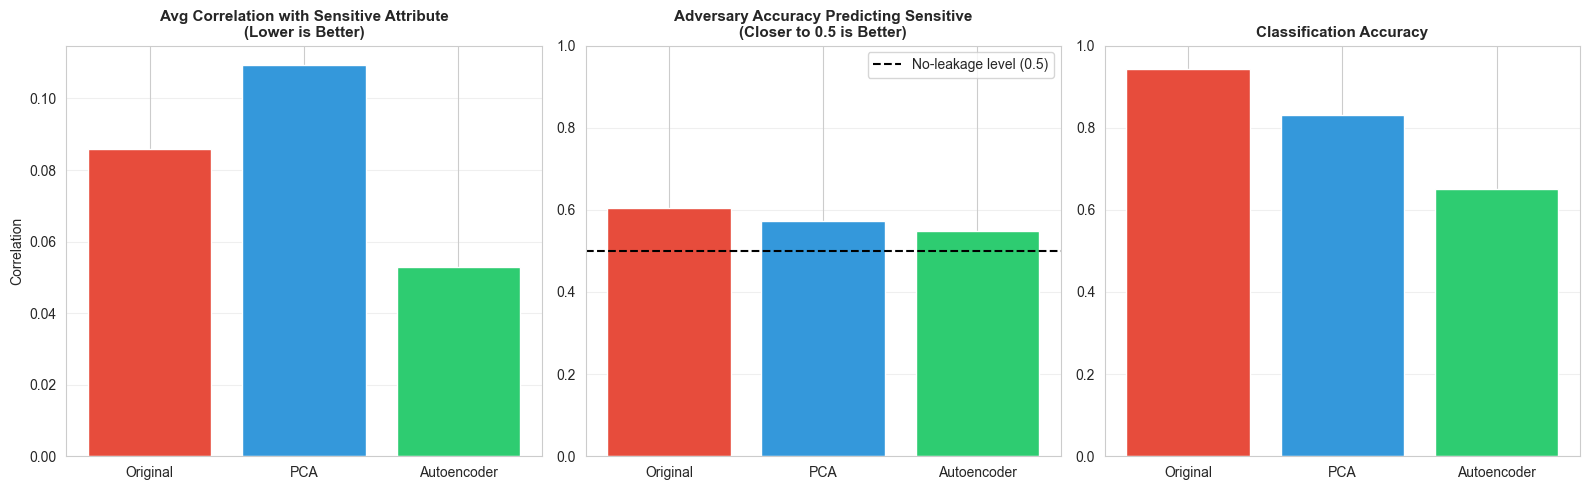

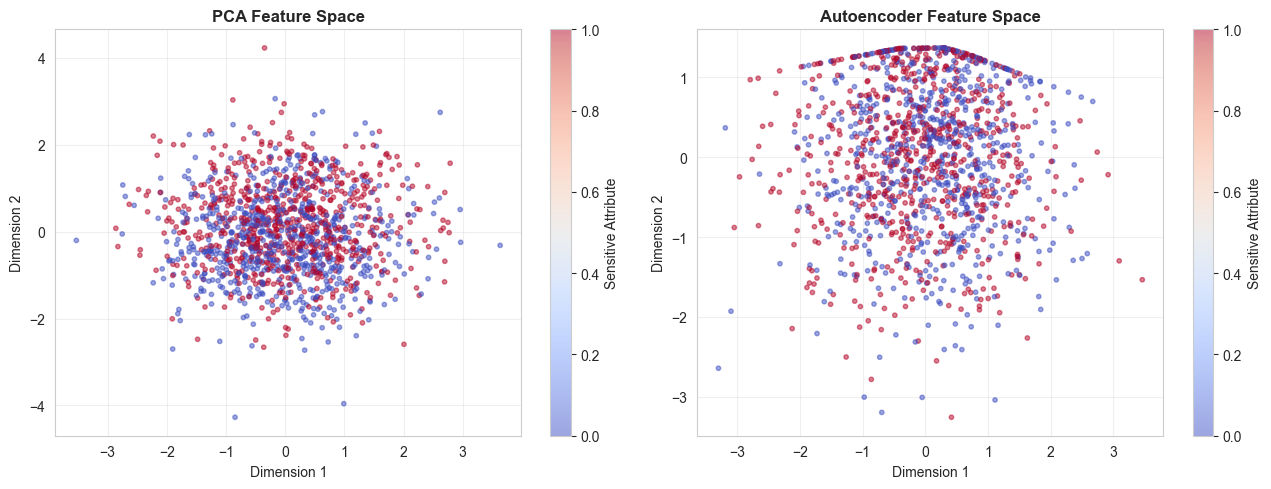

If the two colors are hard to separate in a feature space, that space
carries little sensitive information - compare the two panels.


In [5]:
# Why visualize: bars compare leakage vs accuracy; the scatter plots let you SEE
# whether the two groups are still separable in each learned feature space.

# Step 5: Visualize the comparison

methods = list(results.keys())
colors = ['#e74c3c', '#3498db', '#2ecc71']
correlations = [results[m]['correlation'] for m in methods]
accuracies = [results[m]['accuracy'] for m in methods]
adversaries = [results[m]['adversary'] for m in methods]

# Three panels: residual correlation, adversary accuracy (0.5 = no leakage), task accuracy.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].bar(methods, correlations, color=colors)
axes[0].set_title('Avg Correlation with Sensitive Attribute\n(Lower is Better)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Correlation')
axes[1].bar(methods, adversaries, color=colors)
axes[1].axhline(0.5, color='black', linestyle='--', label='No-leakage level (0.5)')
axes[1].set_title('Adversary Accuracy Predicting Sensitive\n(Closer to 0.5 is Better)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylim([0, 1]); axes[1].legend()
axes[2].bar(methods, accuracies, color=colors)
axes[2].set_title('Classification Accuracy', fontsize=11, fontweight='bold')
axes[2].set_ylim([0, 1])
for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Feature spaces colored by sensitive attribute
# Scatter each 2-D representation colored by group: well-mixed colors = group
# membership is no longer recoverable from the representation.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name in zip(axes, ['PCA', 'Autoencoder']):
    feats = results[name]['features']
    sc = ax.scatter(feats[:, 0], feats[:, 1], c=sensitive_train,
                    cmap='coolwarm', alpha=0.5, s=10)
    ax.set_title(f'{name} Feature Space', fontsize=12, fontweight='bold')
    ax.set_xlabel('Dimension 1'); ax.set_ylabel('Dimension 2')
    ax.grid(alpha=0.3)
    plt.colorbar(sc, ax=ax, label='Sensitive Attribute')
plt.tight_layout()
plt.show()

print("If the two colors are hard to separate in a feature space, that space")
print("carries little sensitive information - compare the two panels.")

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We knew how to detect and mitigate bias, but features may still encode sensitive information.

**AFTER this notebook**: We can:
- ✅ Understand what fair representation means
- ✅ Use PCA to build compressed representations - and *measure* how much sensitive-attribute correlation survives
- ✅ Use autoencoders for feature transformation
- ✅ Understand the adversarial debiasing idea (we used an adversary as a leakage detector)
- ✅ Compare effectiveness of different fair representation methods
- ✅ Choose the right technique for different scenarios

### Key Takeaways

1. **Fair Representation**: Transform features to remove bias at the data level
2. **PCA**: Compression alone does not *target* the sensitive attribute - in our run the adversary got weaker, but average correlation did not drop. Measure, don't assume
3. **Autoencoders**: Learn compressed representations that may remove sensitive information
4. **Adversarial Debiasing**: Makes it hard to predict sensitive attributes from features
5. **Trade-offs**: Balance between fairness and predictive performance

---

## 🚫 When Fair Representation Hits a Limitation

### The Limitation We Discovered

We've learned how to ensure fair representation using PCA, autoencoders, and adversarial techniques. **But there's still a challenge:**

**How do we apply all these techniques to build fair AI systems from the start?**

Fair representation techniques work well when:
- ✅ We have data to transform
- ✅ We can apply feature-level techniques
- ✅ We understand the bias in our data

**But building fair AI systems requires:**
- ❌ **Systematic approach** from data collection to deployment
- ❌ **Best practices** for fair AI development
- ❌ **Integration** of all techniques we've learned
- ❌ **Real-world application** of fairness principles

### Why This Is a Problem

When we have techniques but no systematic approach:
- We may miss important fairness considerations
- We may not apply techniques consistently
- We may not build fairness into the development process
- We may create systems that are fair in some ways but not others

### The Solution: Fair AI Development

We need **systematic fair AI development practices** to:
1. Integrate all fairness techniques we've learned
2. Build fairness into the entire development lifecycle
3. Apply best practices consistently
4. Create truly fair AI systems from the start

**This is exactly what we'll learn in the next notebook: Fair AI Development!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to detect bias (Notebook 1)
- ✅ How to mitigate bias (Notebook 2)
- ✅ How to ensure fair representation (This notebook!)
- ✅ **The limitation**: We need systematic development practices!

**Next notebook**: `05_fair_ai_development.ipynb`
- Learn systematic approaches to fair AI development
- Integrate all fairness techniques
- Build fair AI systems from the start

**Congratulations!** 🎉 You've learned how to ensure fair representation in your features!

## 📚 References

1. Zemel, R., Wu, Y., Swersky, K., Pitassi, T. & Dwork, C. (2013). *Learning Fair Representations*. ICML 2013, PMLR 28. <https://proceedings.mlr.press/v28/zemel13.html>
2. Dwork, C., Hardt, M., Pitassi, T., Reingold, O. & Zemel, R. (2012). *Fairness Through Awareness*. ITCS 2012. <https://arxiv.org/abs/1104.3913>
3. Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K. & Galstyan, A. (2021). *A Survey on Bias and Fairness in Machine Learning*. ACM Computing Surveys, 54(6). <https://arxiv.org/abs/1908.09635>